## Import library

In [ ]:
from utils.eda import *
from utils.preprocessing import *
from utils.config import Config

## Download data

In [3]:
# Download dataset dari mendeley data
download_and_extract_dataset(Config.data_url, Config.zip_name, f'{Config.data_root}/raw')

Dataset already downloaded.
Extracting dataset...
Dataset extracted to data/raw.


In [4]:
# Rename folder hasil ekstraksi
rename_folder(f'{Config.data_root}/raw', Config.folder_mapping)

Renamed 'ECG Images of Myocardial Infarction Patients (240x12=2880)' to 'ECG_MI'.
Renamed 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)' to 'ECG_Abnormal'.
Renamed 'ECG Images of Patient that have History of MI (172x12=2064)' to 'ECG_HistoryMI'.
Renamed 'Normal Person ECG Images (284x12=3408)' to 'ECG_Normal'.


## Exploratory Data Analysis

### Count data

In [2]:
# Count data
display(count_dataset(f'{Config.data_root}/raw'))

,folder,count
0,ECG_Abnormal,233
1,ECG_HistoryMI,172
2,ECG_MI,239
3,ECG_Normal,284


### Preview data

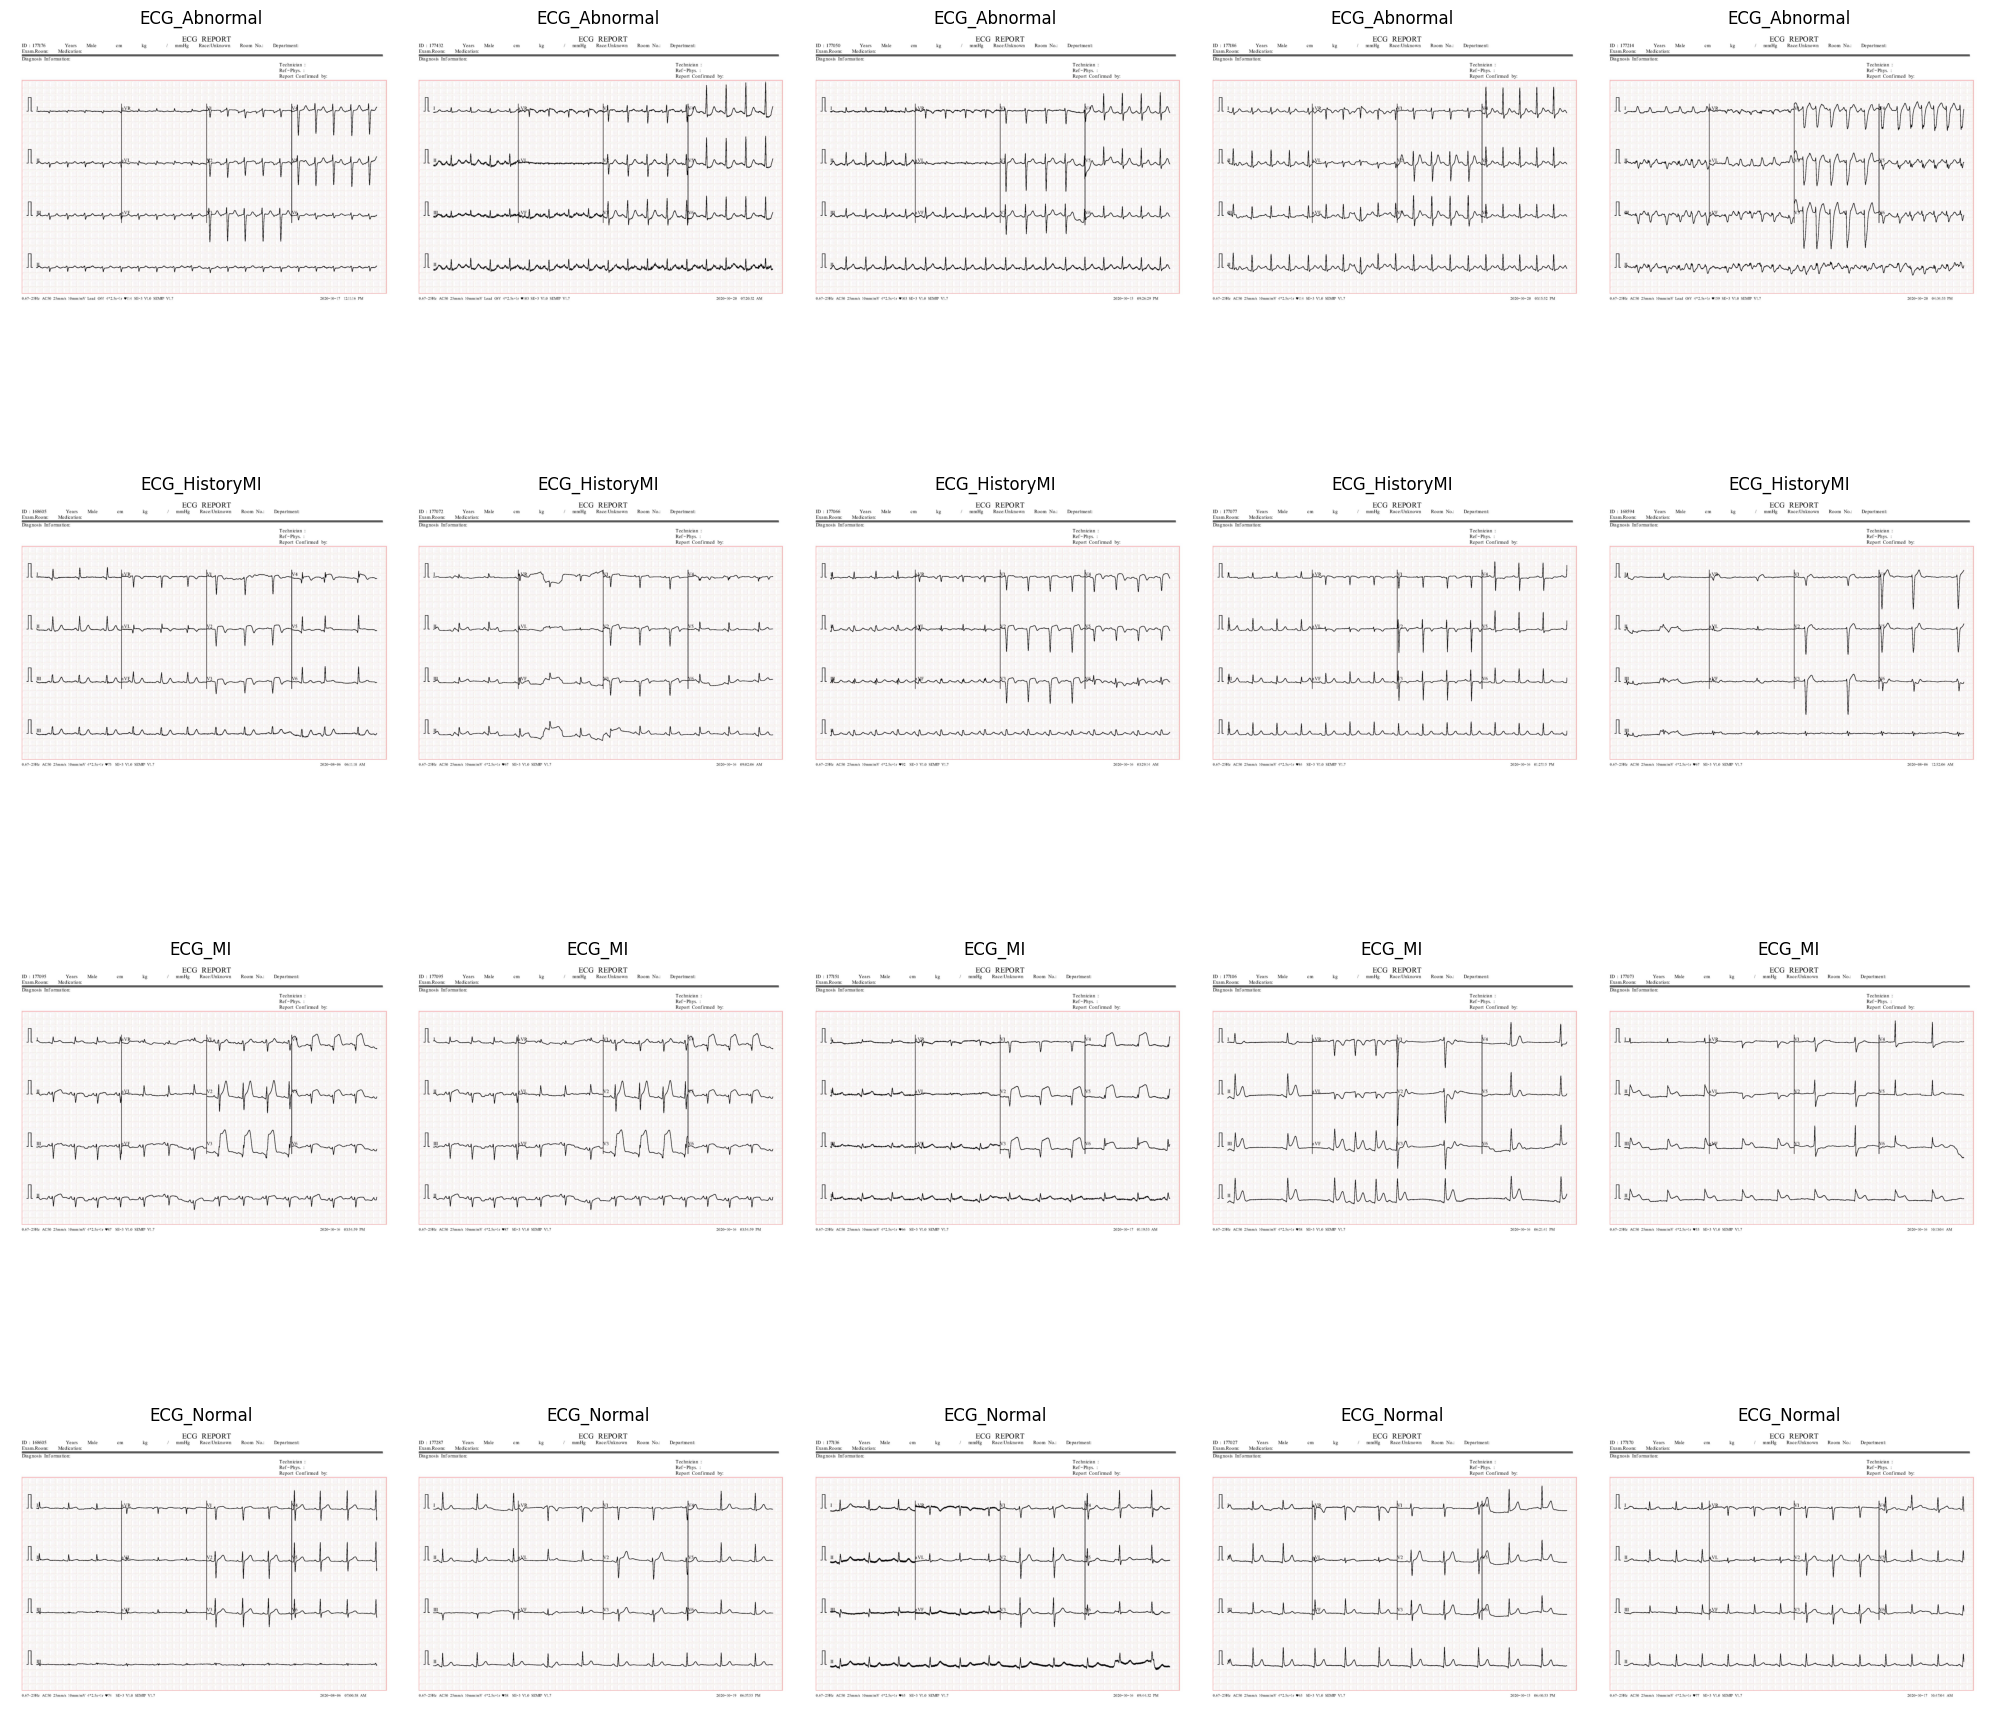

In [3]:
preview_images(f'{Config.data_root}/raw', num_images=5, random=True)

## Preprocessing

### Crop ecg area preview

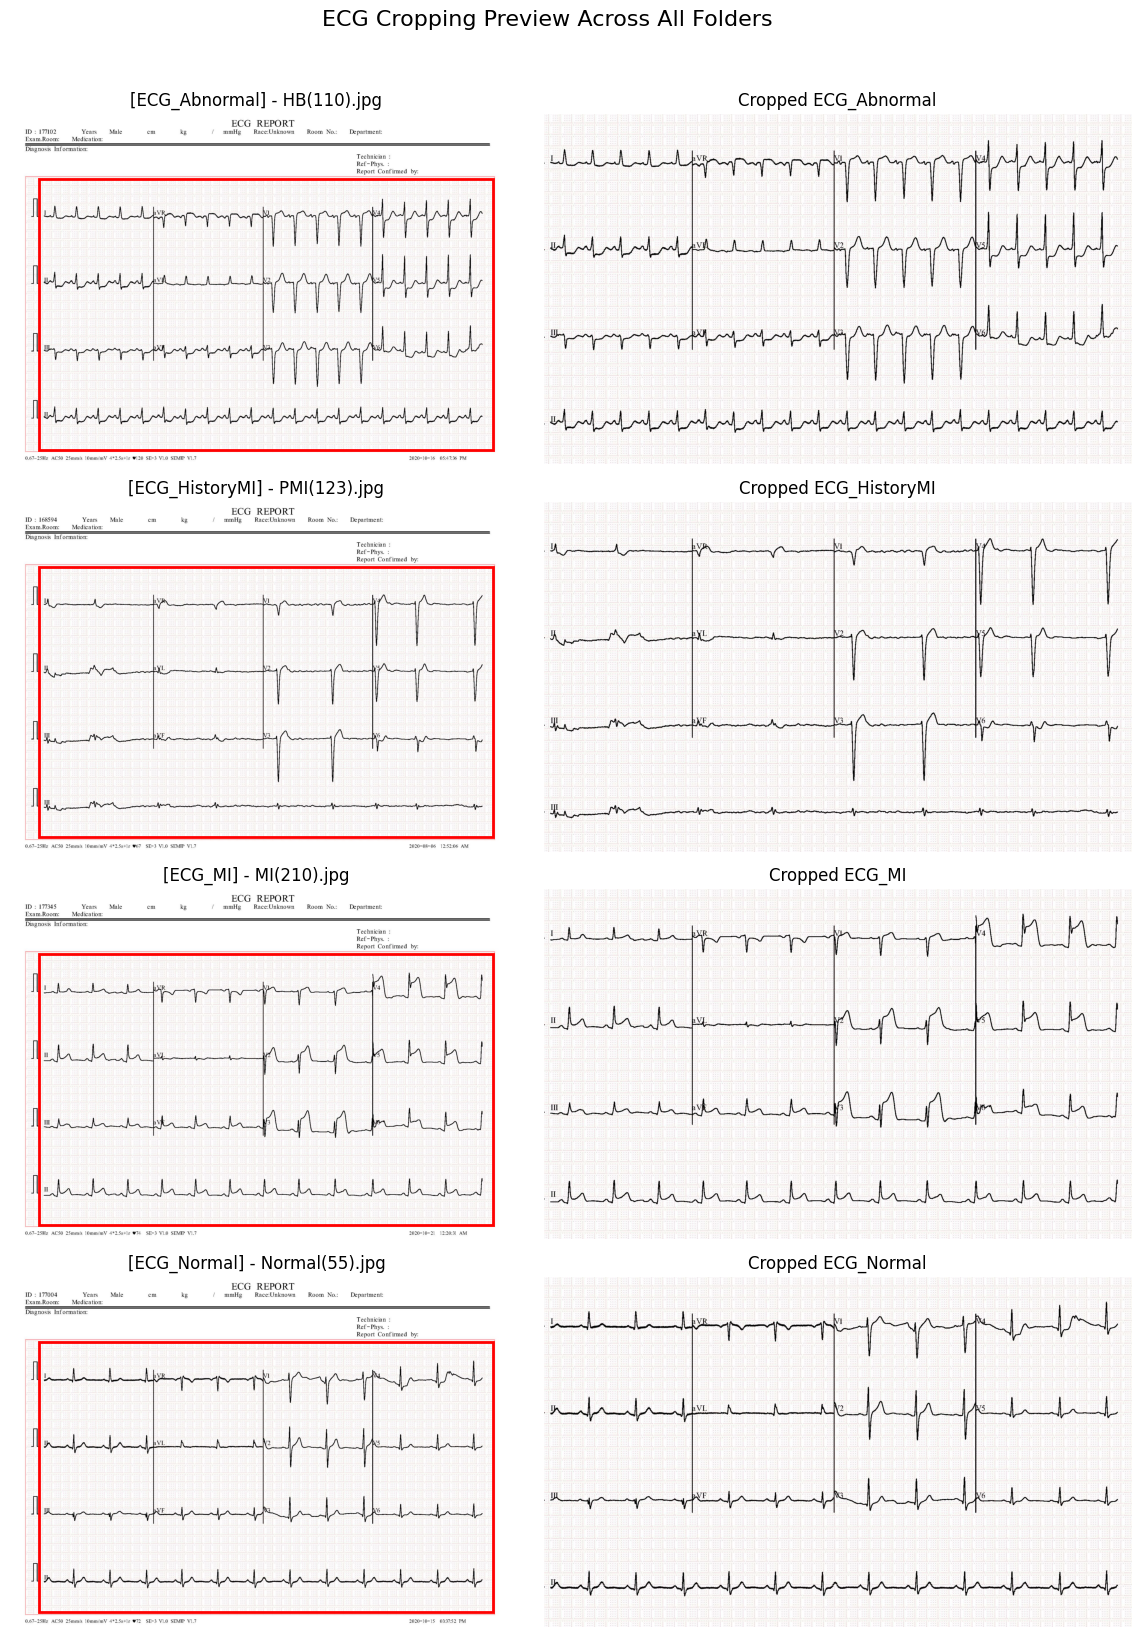

In [4]:
preview_cropped_ecg_area(f'{Config.data_root}/raw',Config.ecg_area_coordinates,random=True)

### Crop ecg area

In [11]:
crop_ecg_area(f'{Config.data_root}/raw', f'{Config.data_root}/preprocessed', Config.ecg_area_coordinates)

Cropping ECG_Normal: 100%|██████████| 284/284 [00:05<00:00, 52.58it/s]


### Extract ecg signal preview

In [ ]:
preview_extract_ecg_signal(f'{Config.data_root}/preprocessed/crop_ecg_area', random=True)

### Extract ecg signal

In [4]:
extract_ecg_signal(f'{Config.data_root}/preprocessed/crop_ecg_area', f'{Config.data_root}/preprocessed')

Cleaning ECG_Normal: 100%|██████████| 284/284 [00:20<00:00, 13.59it/s]


### Create template for text mask

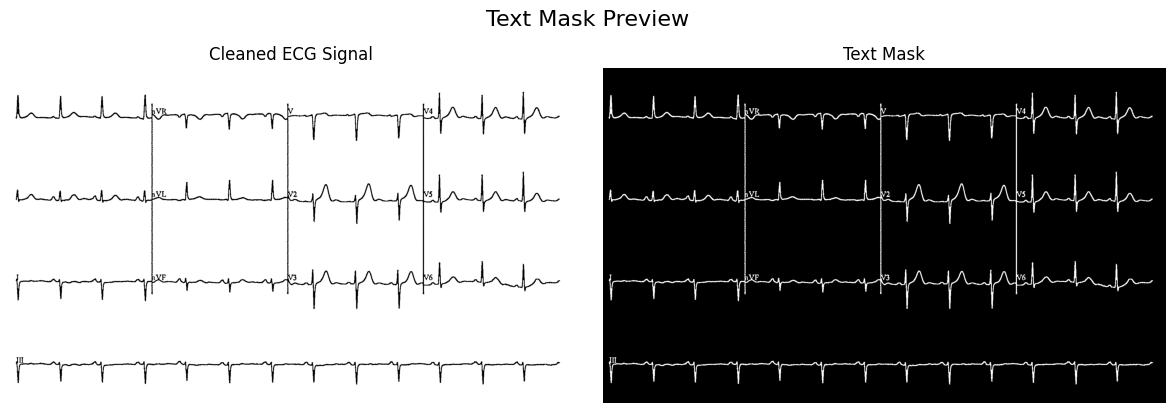

In [5]:
create_text_mask(f'{Config.data_root}/preprocessed/crop_ecg_area', f'{Config.data_root}/preprocessed')

### Delete text preview

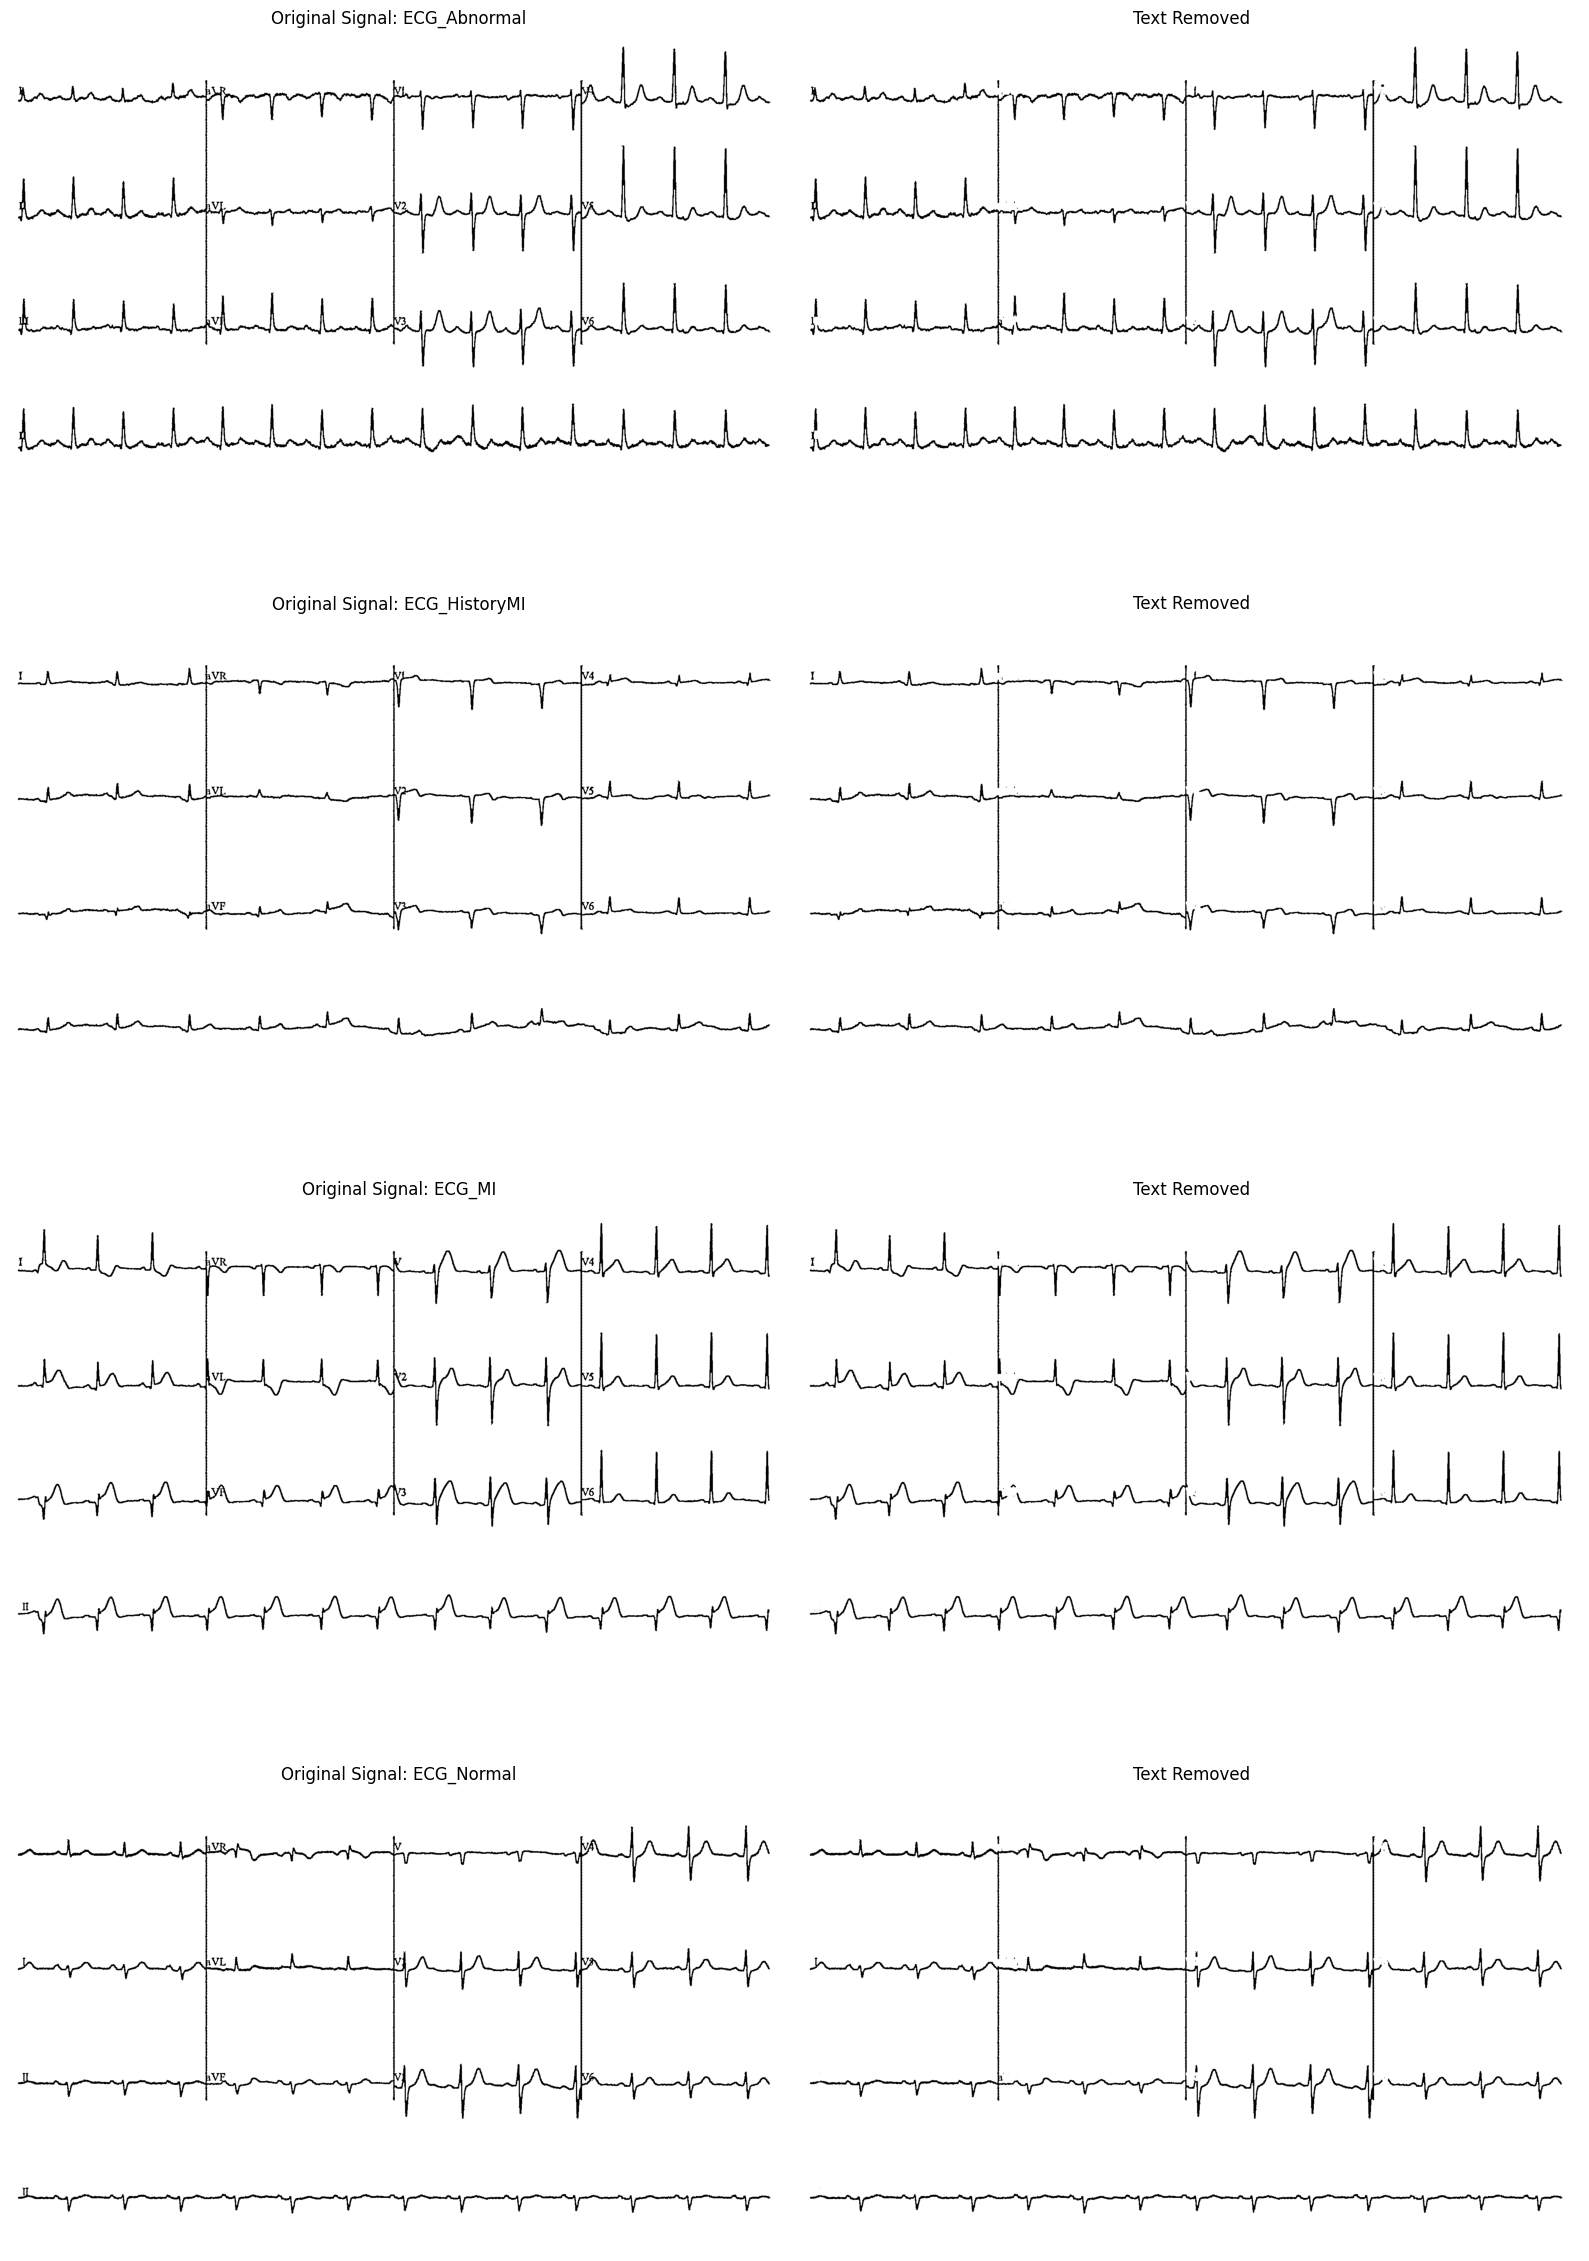

In [2]:
preview_delete_text(f'{Config.data_root}/preprocessed/extracted_ecg_signal', 'utils/text_mask.png', random=True)

### Delete text

In [3]:
delete_text_from_ecg(f'{Config.data_root}/preprocessed/extracted_ecg_signal', f'{Config.data_root}/preprocessed/clean_ecg_signal', 'utils/text_mask.png')

Removing Text ECG_Normal: 100%|██████████| 284/284 [00:40<00:00,  6.97it/s]


### Crop short and long leads preview

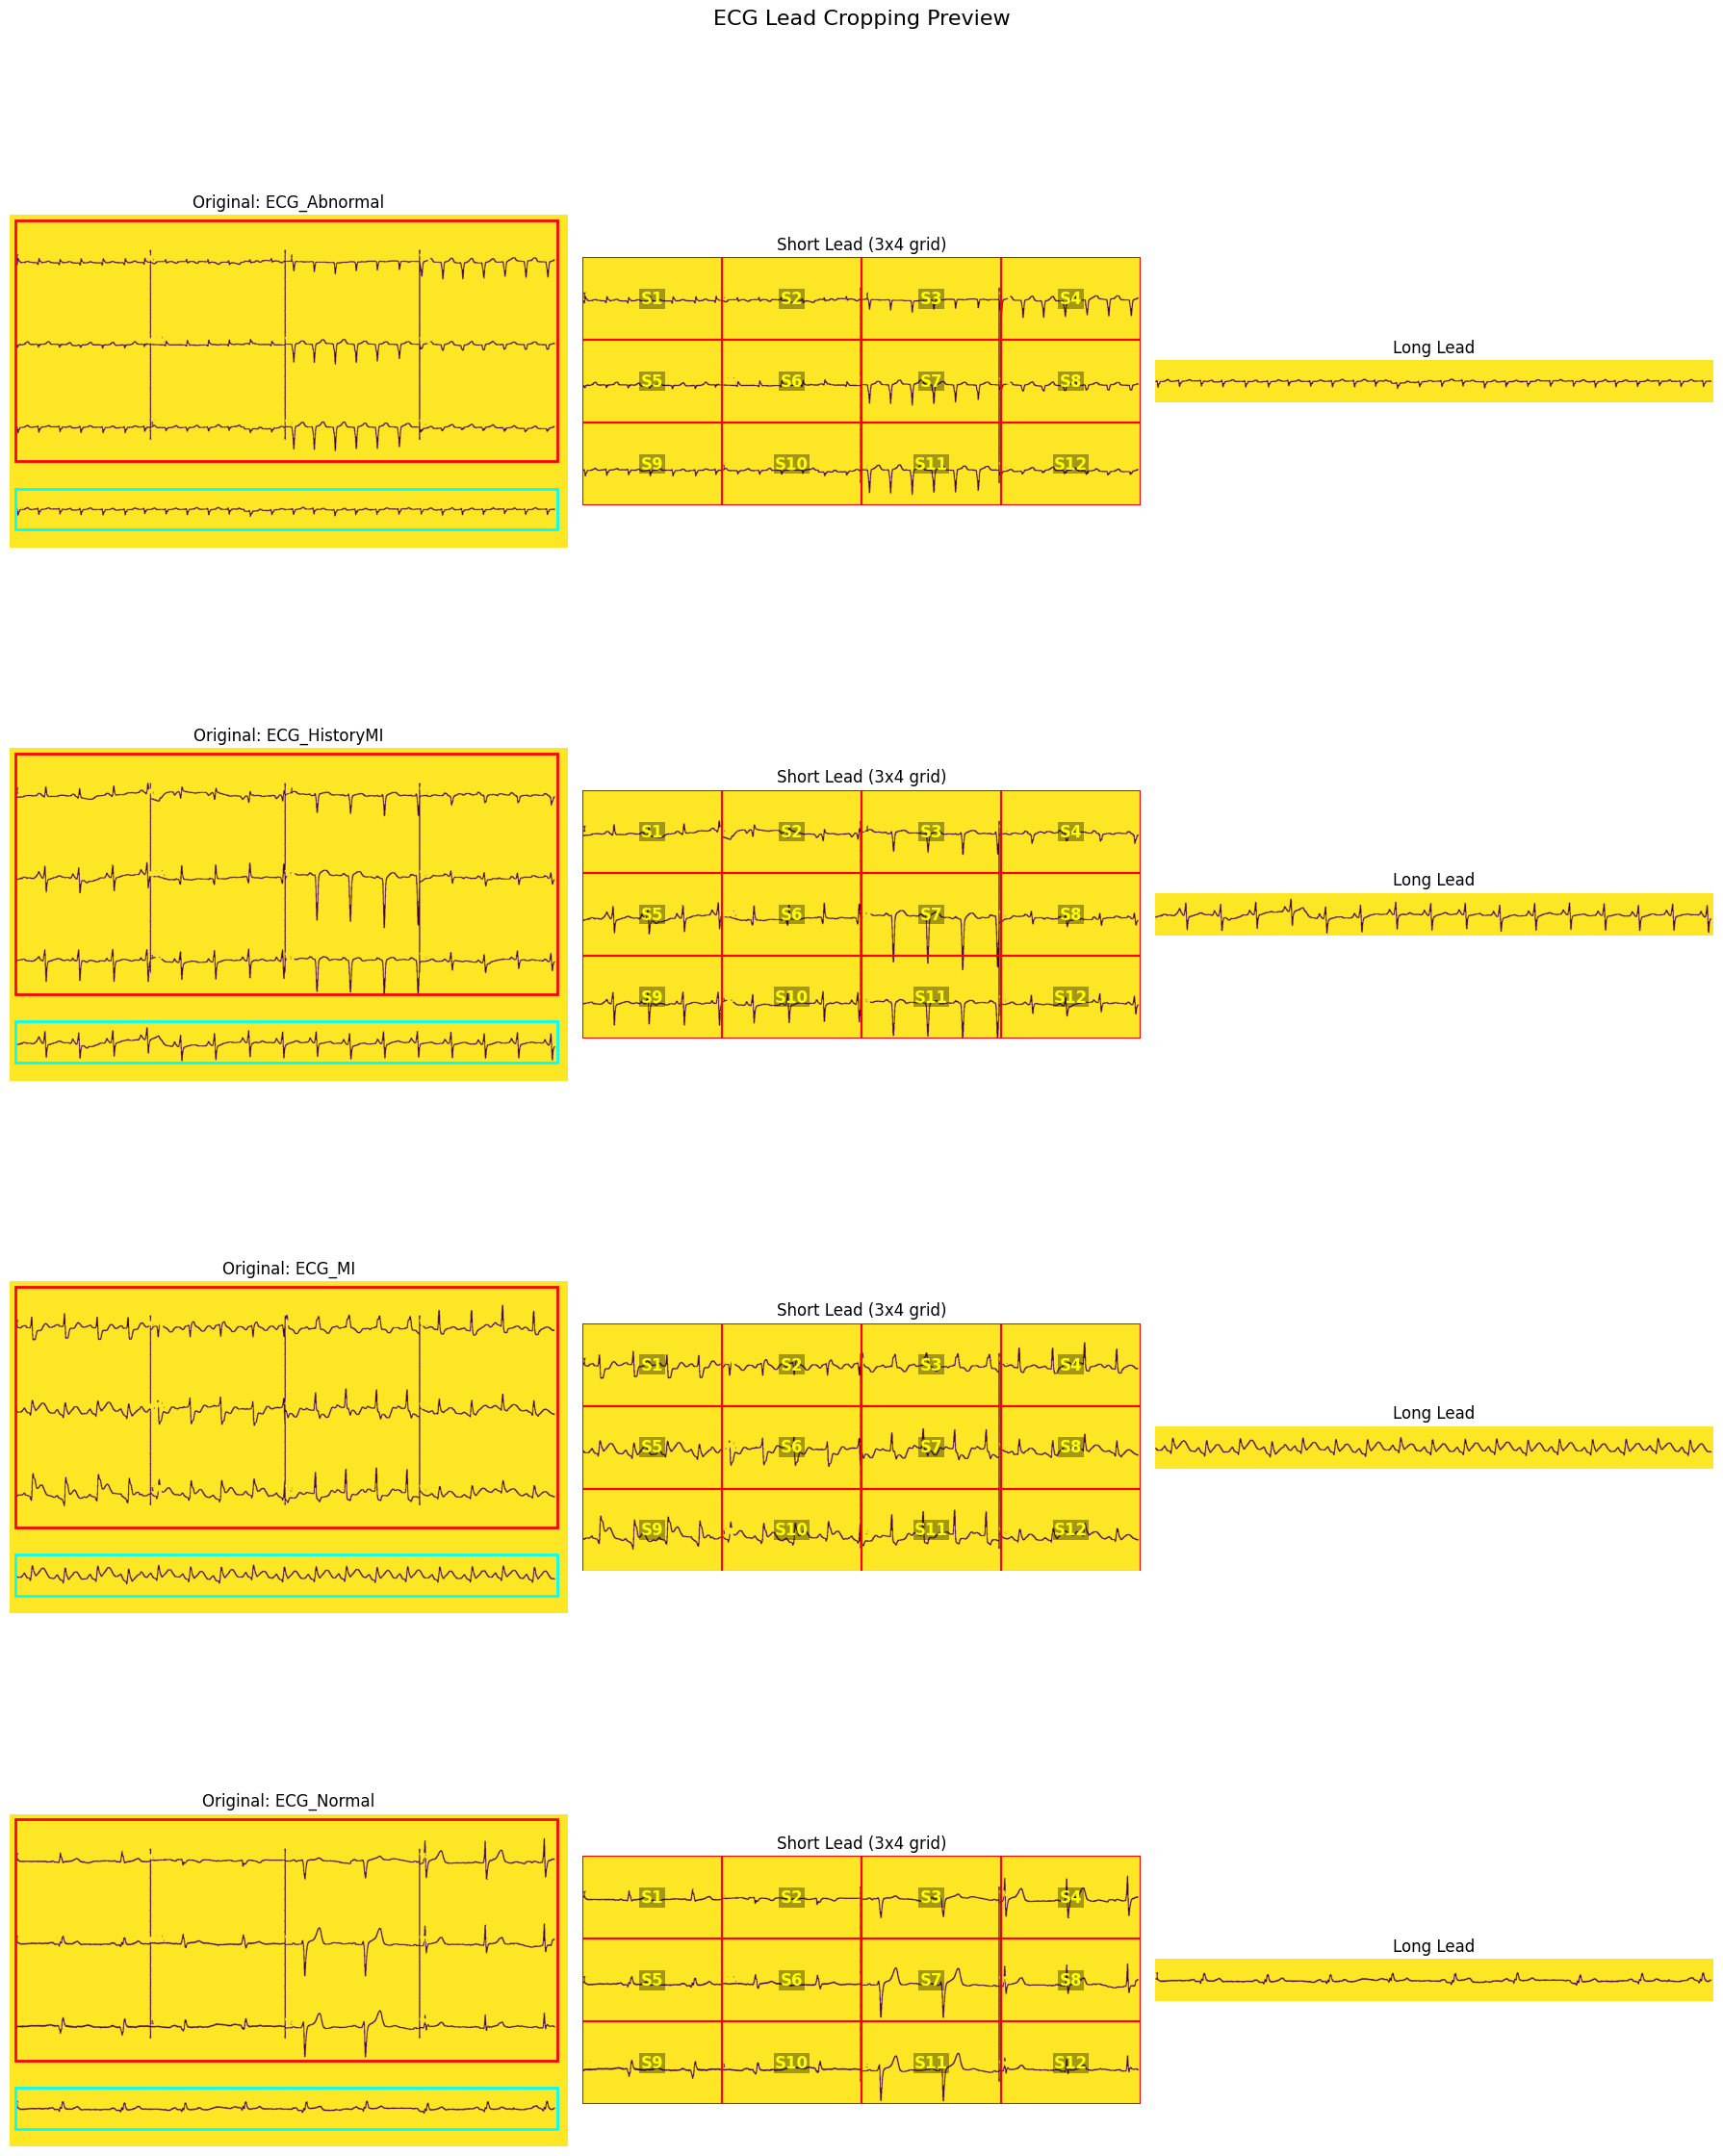

In [ ]:
preview_cropped_short_and_long_leads(f'{Config.data_root}/preprocessed/clean_ecg_signal', random=True,
                                   coordinate_short=Config.short_lead_coordinates,
                                   coordinate_long=Config.long_lead_coordinates)

### Crop short and long leads

In [ ]:
crop_short_and_long_leads(f'{Config.data_root}/preprocessed/clean_ecg_signal', f'{Config.data_root}/preprocessed/cropped_leads', 
                         Config.short_lead_coordinates, Config.long_lead_coordinates, Config.lead_mapping)

Processing ECG_Normal: 100%|██████████| 284/284 [00:16<00:00, 16.81it/s]
